In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import pickle as pkl
import networkx as nx
import matplotlib.pyplot as plt

import good
from good.reload import deep_reload

This nodebook shows an example of how to run GOOD for a pre-build graph. In this case the WECC example graph is loaded and run for 7 days with results plotted. The same is done with flexible base loads in the second example.

In [2]:
'''
Loading WECC Graph
'''
deep_reload(good)

wecc = good.graph.graph_from_json('Examples/WECC.json')

In [3]:
wecc.nodes

NodeView(('WA', 'OR', 'CA', 'ID', 'NV', 'UT', 'AZ', 'MT', 'WY', 'CO', 'NM', 'WECC_AZ', 'WECC_CO', 'WECC_ID', 'WECC_IID', 'WECC_MT', 'WECC_NM', 'WECC_NNV', 'WECC_PNW', 'WECC_SCE', 'WECC_SNV', 'WECC_UT', 'WECC_WY'))

In [4]:
'''
Building from graph
'''
deep_reload(good)

kw = {
    'verbose': True,
    'steps': 24 * 7,
    'shortfall_capacity': np.inf,
    'shortfall_cost': 1e3,
    'wastage_capacity': np.inf,
    'wastage_cost': 1e3,
}

network = good.optimization.network.Network(**kw).from_graph(wecc)

'''
Building the model
'''

network.build()

Parameters Built: 0.6778926849365234
Variables Built: 0.40310192108154297
Constraints Built: 2.2875428199768066
Objective Built: 0.6943943500518799


In [5]:
'''
Solving the model
'''
deep_reload(good)

kw = {
    'solver': {
        '_name': 'cbc',
    },
}

network.solve(**kw)
results = network.results

Problem Solved: 13.523029565811157
Results Collected: 0.6103005409240723


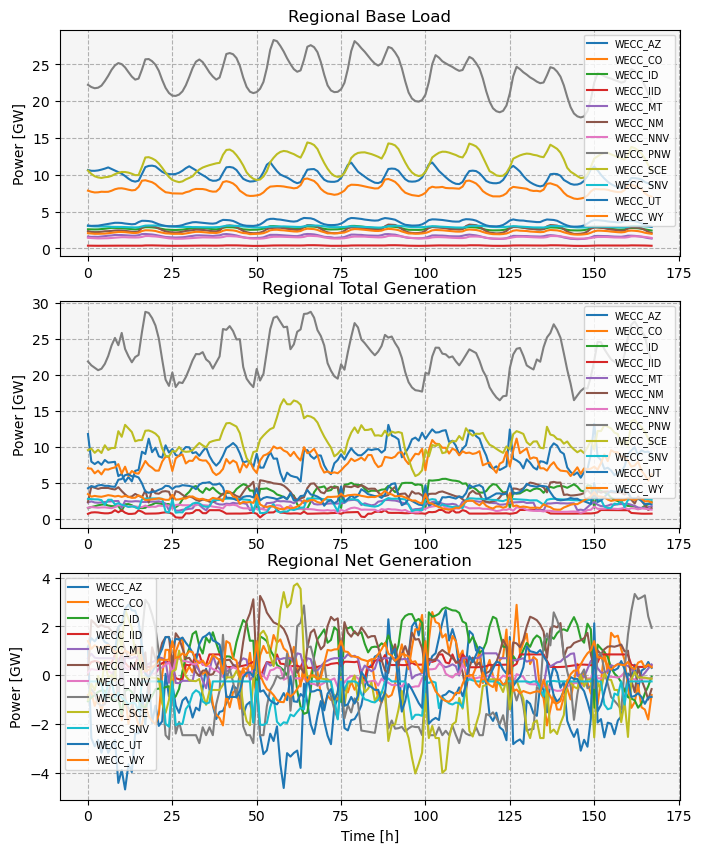

In [6]:
fig, ax = plt.subplots(3, 1, figsize = (8, 10))

for source, node in wecc._node.items():
    if 'assets' in results[source]:

        ax[0].plot(
            -np.array(results[source]['assets'][f"base_load_{source}"]['net']) / 1e9,
            label = source,
        )
        
        ax[0].set_title('Regional Base Load')

for source, node in wecc._node.items():
    if 'assets' in results[source]:

        values = np.vstack(
            [v["net"] for k, v in results[source]['assets'].items() if "base" not in k]
        )

        ax[1].plot(
            values.sum(axis = 0) / 1e9,
            label = source,
        )

        ax[1].set_title('Regional Total Generation')

for source, node in wecc._node.items():
    if 'assets' in results[source]:

        values = np.vstack(
            [v["net"] for k, v in results[source]['assets'].items()]
        )

        ax[2].plot(
            values.sum(axis = 0) / 1e9,
            label = source,
        )

        ax[2].set_title('Regional Net Generation')
        ax[2].set_xlabel('Time [h]')

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = [ax.set(**kw) for ax in ax]

kw = {
    'ls': '--',
}

_ = [ax.grid(**kw) for ax in ax]

kw = {
    'fontsize': 'x-small',
}

_ = [ax.legend(**kw) for ax in ax]

In [7]:
'''
Loading WECC Graph - with shifable base load
'''
deep_reload(good)

wecc = good.graph.graph_from_json('Examples/WECC.json')

for source, node in wecc._node.items():
    for asset in node.get('assets', []):
        if asset['type'] == 'load':

            asset['shift_portion'] = .5

In [11]:
nodes = ['WECC_SCE', 'WECC_PNW', 'WECC_SNV']

wecc = good.graph.subgraph(wecc, nodes)

In [12]:
'''
Building from graph
'''
deep_reload(good)

kw = {
    'verbose': True,
    'steps': 24 * 7,
    'shortfall_capacity': np.inf,
    'shortfall_cost': 1e3,
    'wastage_capacity': np.inf,
    'wastage_cost': 1e3,
}

network = good.optimization.network.Network(**kw).from_graph(wecc)

'''
Building the model
'''

network.build()

Parameters Built: 0.14214396476745605
Variables Built: 0.08740568161010742
Constraints Built: 1.0481915473937988
Objective Built: 0.24221134185791016


In [13]:
'''
Solving the model
'''
deep_reload(good)

kw = {
    'solver': {
        '_name': 'cbc',
    },
}

network.solve(**kw)
results = network.results

Problem Solved: 1.4098286628723145
Results Collected: 0.04505348205566406


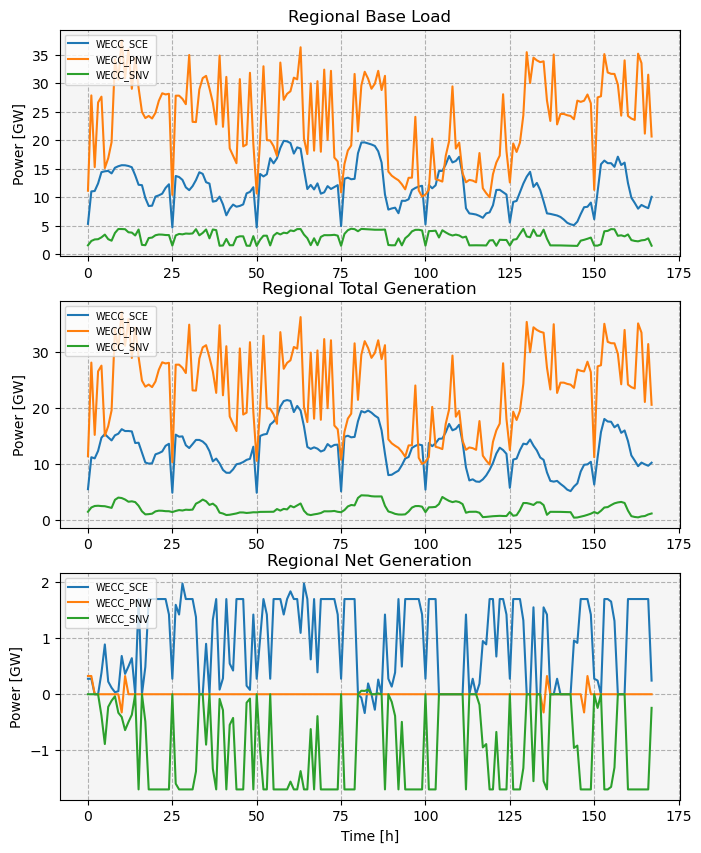

In [14]:
fig, ax = plt.subplots(3, 1, figsize = (8, 10))

for source, node in wecc._node.items():
    if 'assets' in results[source]:

        ax[0].plot(
            -np.array(results[source]['assets'][f"base_load_{source}"]['net']) / 1e9,
            label = source,
        )
        
        ax[0].set_title('Regional Base Load')

for source, node in wecc._node.items():
    if 'assets' in results[source]:

        values = np.vstack(
            [v["net"] for k, v in results[source]['assets'].items() if "base" not in k]
        )

        ax[1].plot(
            values.sum(axis = 0) / 1e9,
            label = source,
        )

        ax[1].set_title('Regional Total Generation')

for source, node in wecc._node.items():
    if 'assets' in results[source]:

        values = np.vstack(
            [v["net"] for k, v in results[source]['assets'].items()]
        )

        ax[2].plot(
            values.sum(axis = 0) / 1e9,
            label = source,
        )

        ax[2].set_title('Regional Net Generation')
        ax[2].set_xlabel('Time [h]')

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = [ax.set(**kw) for ax in ax]

kw = {
    'ls': '--',
}

_ = [ax.grid(**kw) for ax in ax]

kw = {
    'fontsize': 'x-small',
}

_ = [ax.legend(**kw) for ax in ax]